In [ ]:
!pip install matplotlib seaborn plotly altair pandas numpy -q

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

sns.set_theme(style="darkgrid")
print("Библиотеки загружены!")

Библиотеки загружены!


In [ ]:
# Генерация банковского датасета (как в предыдущих уроках)
np.random.seed(42)
N = 2000
cities = ['Москва', 'Санкт-Петербург', 'Казань', 'Новосибирск', 'Екатеринбург']
df = pd.DataFrame({
    'client_id': range(1001, 1001 + N),
    'city': np.random.choice(cities, N),
    'age': np.random.randint(21, 70, N),
    'income': np.random.normal(50000, 20000, N).astype(int),
    'loan_amount': np.random.normal(200000, 80000, N).astype(int),
    'credit_score': np.random.normal(650, 100, N).astype(int),
    'default': np.random.choice([0, 1], N, p=[0.9, 0.1])
})
df['income'] = df['income'].clip(lower=0)
df['loan_amount'] = df['loan_amount'].clip(lower=0)
print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Датасет: 2000 строк, 7 колонок


,client_id,city,age,income,loan_amount,credit_score,default
0,1001,Новосибирск,48,20976,216762,913,0
1,1002,Екатеринбург,27,49758,112669,680,0
2,1003,Казань,52,24952,218707,611,0
3,1004,Екатеринбург,31,57272,282835,429,0
4,1005,Екатеринбург,30,67737,133115,788,0


## Matplotlib — полный контроль, много кода

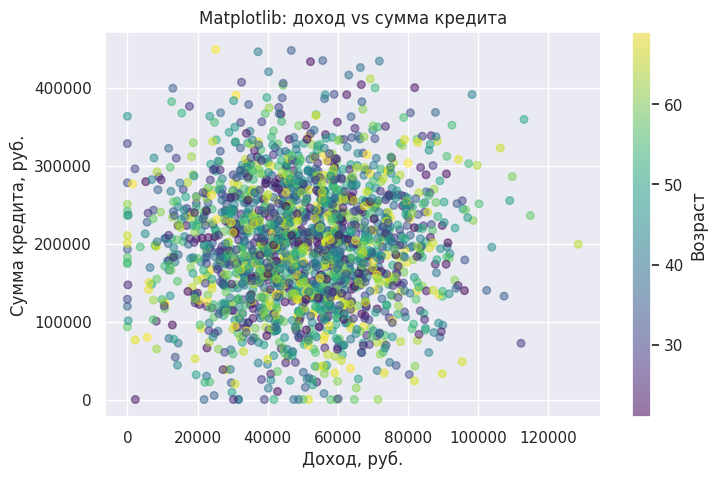

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['income'], df['loan_amount'],
                     alpha=0.5, c=df['age'], cmap='viridis', s=30)
ax.set_title('Matplotlib: доход vs сумма кредита')
ax.set_xlabel('Доход, руб.')
ax.set_ylabel('Сумма кредита, руб.')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Возраст')
plt.show()

**Когда использовать:** нестандартные отчёты, полный контроль над каждой точкой.

## Seaborn — стиль и статистика из "коробки"

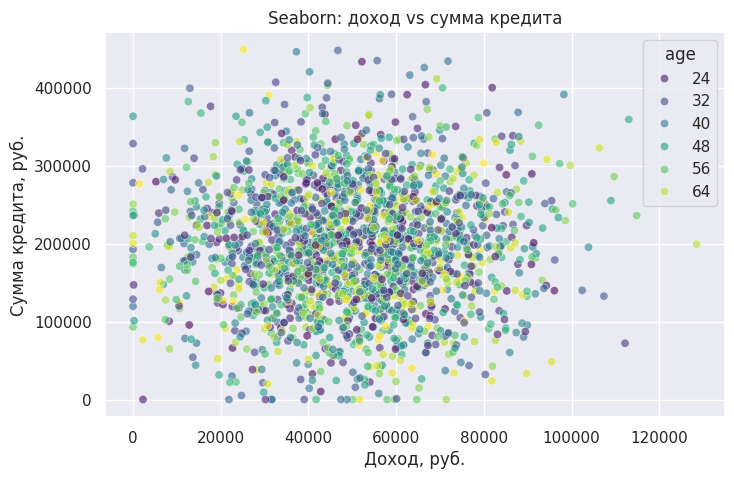

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='income', y='loan_amount', hue='age', palette='viridis', alpha=0.6)
plt.title('Seaborn: доход vs сумма кредита')
plt.xlabel('Доход, руб.')
plt.ylabel('Сумма кредита, руб.')
plt.show()

**Когда использовать:** быстрый EDA, сравнение групп, pairplot, heatmap.

## Plotly Express — интерактив и подсказки

In [ ]:
fig = px.scatter(df, x='income', y='loan_amount', color='age',
                 hover_name='client_id', hover_data=['city'],
                 title='Plotly: доход vs сумма кредита',
                 labels={'income':'Доход, руб.', 'loan_amount':'Сумма кредита, руб.'})
fig.show()

**Когда использовать:** презентации, дашборды, интерактивное исследование.

## Altair — декларативный подход

In [ ]:
alt.Chart(df).mark_circle(opacity=0.5).encode(
    x='income:Q',
    y='loan_amount:Q',
    color=alt.Color('age:Q', scale=alt.Scale(scheme='viridis')),
    tooltip=['client_id', 'income', 'loan_amount', 'city']
).properties(
    title='Altair: доход vs сумма кредита',
    width=600,
    height=400
).interactive()

alt.Chart(...)

**Когда использовать:** академические презентации, прототипы, лаконичный код.

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Построй один и тот же boxplot дохода по городам в Matplotlib, Seaborn и Plotly. Сравни код.
2. Создай bar chart среднего кредитного скоринга по городам в Seaborn и Plotly. Какой занял меньше строк?
3. Попробуй Altair для пары любых переменных из датасета. Оцени синтаксис.


In [ ]:
# твой код